<a href="https://colab.research.google.com/github/hailehong2002/DQN-Agent-ALE-Freeway-v5/blob/main/notebooks/sessions/7_dqn/dqn_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo](https://raw.githubusercontent.com/BartaZoltan/deep-reinforcement-learning-course/main/notebooks/shared_assets/logo.png)

# Practice 7 Homework: Train a DQN Agent on a Non-Pong Atari Environment

**Developers:** Zoltan Barta  
**Date:** 2026-04-13  
**Version:** 2025-26/2

[<img src="https://colab.research.google.com/assets/colab-badge.svg">](https://colab.research.google.com/github/BartaZoltan/deep-reinforcement-learning-course/blob/main/notebooks/sessions/7_dqn/dqn_homework.ipynb)

## Task Description

In this homework, your task is to choose **one Atari environment other than Pong** and train a **Deep Q-Network (DQN)** agent on it.

You should implement the full pipeline yourself. This includes environment creation and preprocessing, the replay buffer, the Q-network, the DQN target computation, the training loop, and the final evaluation. No starter implementation is provided on purpose: the goal is to transfer the ideas from the session notebook into a new Atari setting independently.

Use the same overall DQN logic as in the practice material: image-based Atari observations, standard DQN preprocessing, experience replay, a target network, epsilon-greedy exploration, and greedy evaluation.

`Pong` is not allowed for this homework.


In [2]:
# Help cell: list Atari environments that are allowed for this homework.
try:
    import gymnasium as gym
    import ale_py
except Exception as exc:
    raise ImportError(
        "This homework requires gymnasium with Atari support and ale-py."
    ) from exc

gym.register_envs(ale_py)

atari_env_ids = sorted(
    spec.id
    for spec in gym.registry.values()
    if spec.id.startswith("ALE/")
    and spec.id.endswith("-v5")
    and "Pong" not in spec.id
)

print(f"Available Atari environments excluding Pong: {len(atari_env_ids)}")
for env_id in atari_env_ids:
    print(" -", env_id)

recommended = [
    env_id
    for env_id in [
        "ALE/Breakout-v5",
        "ALE/Boxing-v5",
        "ALE/Freeway-v5",
        "ALE/Enduro-v5",
    ]
    if env_id in atari_env_ids
]

print("\nRecommended starter choices:")
for env_id in recommended:
    print(" -", env_id)


Available Atari environments excluding Pong: 103
 - ALE/Adventure-v5
 - ALE/AirRaid-v5
 - ALE/Alien-v5
 - ALE/Amidar-v5
 - ALE/Assault-v5
 - ALE/Asterix-v5
 - ALE/Asteroids-v5
 - ALE/Atlantis-v5
 - ALE/Atlantis2-v5
 - ALE/Backgammon-v5
 - ALE/BankHeist-v5
 - ALE/BasicMath-v5
 - ALE/BattleZone-v5
 - ALE/BeamRider-v5
 - ALE/Berzerk-v5
 - ALE/Blackjack-v5
 - ALE/Bowling-v5
 - ALE/Boxing-v5
 - ALE/Breakout-v5
 - ALE/Carnival-v5
 - ALE/Casino-v5
 - ALE/Centipede-v5
 - ALE/ChopperCommand-v5
 - ALE/CrazyClimber-v5
 - ALE/Crossbow-v5
 - ALE/Darkchambers-v5
 - ALE/Defender-v5
 - ALE/DemonAttack-v5
 - ALE/DonkeyKong-v5
 - ALE/DoubleDunk-v5
 - ALE/Earthworld-v5
 - ALE/ElevatorAction-v5
 - ALE/Enduro-v5
 - ALE/Entombed-v5
 - ALE/Et-v5
 - ALE/FishingDerby-v5
 - ALE/FlagCapture-v5
 - ALE/Freeway-v5
 - ALE/Frogger-v5
 - ALE/Frostbite-v5
 - ALE/Galaxian-v5
 - ALE/Gopher-v5
 - ALE/Gravitar-v5
 - ALE/Hangman-v5
 - ALE/HauntedHouse-v5
 - ALE/Hero-v5
 - ALE/HumanCannonball-v5
 - ALE/IceHockey-v5
 - ALE/Ja

**IMPORT AND DEVICE**

In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import matplotlib.pyplot as plt
import imageio

gym.register_envs(ale_py)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


**ENVIRONMENT SETUP**

In [4]:
ENV_ID = "ALE/Freeway-v5"

def make_atari_env(
    env_id: str = ENV_ID,
    render_mode: str | None = None,
    seed: int | None = None,
    frame_skip: int = 4,
    stack_size: int = 4,
    screen_size: int = 84
):
    """Create a Pong environment with standard DQN-style preprocessing."""
    env = gym.make(
        env_id,
        render_mode=render_mode,
        frameskip=1,
        repeat_action_probability=0.0,
        full_action_space=False,
    )
    env = AtariPreprocessing(
        env,
        frame_skip=frame_skip,
        screen_size=screen_size,
        grayscale_obs=True,
        scale_obs=False,
        terminal_on_life_loss=False,
    )
    env = FrameStackObservation(env, stack_size)
    if seed is not None:
        env.reset(seed=seed)
    return env

In [5]:
#CHECKING
_env = make_atari_env(seed=0)
obs, _ = _env.reset()
print(f"Observation shape: {obs.shape}")  # should be (4, 84, 84)
print(f"Number of actions: {_env.action_space.n}")  # should be 3 for Freeway
_env.close()

Observation shape: (4, 84, 84)
Number of actions: 3


**ReplayBuffer**

In [6]:
class ReplayBuffer:
    def __init__(self, capacity: int, obs_shape: tuple[int, ...], device):
        self.capacity = int(capacity)
        self.device = device
        self.obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
        self.size = 0

    def add(self, obs, action: int, reward: float, next_obs, done: bool):
        self.obs[self.pos] = np.asarray(obs, dtype=np.uint8)
        self.next_obs[self.pos] = np.asarray(next_obs, dtype=np.uint8)
        self.actions[self.pos] = int(action)
        self.rewards[self.pos] = float(reward)
        self.dones[self.pos] = float(done)
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int) -> dict[str, torch.Tensor]:
        indices = np.random.randint(0, self.size, size=batch_size)
        return {
            'obs': torch.as_tensor(self.obs[indices], dtype=torch.float32, device=self.device) / 255.0,
            'actions': torch.as_tensor(self.actions[indices], dtype=torch.long, device=self.device),
            'rewards': torch.as_tensor(self.rewards[indices], dtype=torch.float32, device=self.device),
            'next_obs': torch.as_tensor(self.next_obs[indices], dtype=torch.float32, device=self.device) / 255.0,
            'dones': torch.as_tensor(self.dones[indices], dtype=torch.float32, device=self.device),
        }

    def __len__(self) -> int:
        return self.size

**Q-NETWORK**

In [7]:
class QNetwork(nn.Module):
    def __init__(self, obs_shape: tuple[int, ...], num_actions: int):
        super().__init__()
        channels, _, _ = obs_shape

        self.features = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, *obs_shape, dtype=torch.float32)
            feature_dim = int(self.features(dummy).reshape(1, -1).shape[1])
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.head(x)

In [8]:
#CHECKING
q_net = QNetwork(obs_shape=obs.shape, num_actions=_env.action_space.n).to(DEVICE)
obs_batch = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0) / 255.0
q_values = q_net(obs_batch)

print(f"Input shape:    {obs_batch.shape}")   # (1, 4, 84, 84)
print(f"Output shape:   {q_values.shape}")    # (1, 3) — 3 actions for Freeway
print(f"Q-values:       {q_values}")
print(f"Total params:   {sum(p.numel() for p in q_net.parameters()):,}")
_env.close()

Input shape:    torch.Size([1, 4, 84, 84])
Output shape:   torch.Size([1, 3])
Q-values:       tensor([[ 0.0422, -0.0384,  0.0407]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Total params:   1,685,667


**DQN Targets and Optimization**



In [9]:
def compute_dqn_targets(
    *,
    rewards: torch.Tensor,
    dones: torch.Tensor,
    next_obs: torch.Tensor,
    online_net: nn.Module,
    target_net: nn.Module,
    gamma: float,
) -> torch.Tensor:
    with torch.no_grad():
        next_q = target_net(next_obs).max(dim=1).values
        return rewards + gamma * (1.0 - dones) * next_q

def dqn_train_step(
    online_net: nn.Module,
    target_net: nn.Module,
    optimizer,
    batch: dict[str, torch.Tensor],
    gamma: float,
    *,
    target_builder_fn=compute_dqn_targets,
    max_grad_norm: float = 10.0,
) -> dict[str, float]:
    current_q = online_net(batch['obs']).gather(1, batch['actions'].unsqueeze(1)).squeeze(1)
    targets = target_builder_fn(
        rewards=batch['rewards'],
        dones=batch['dones'],
        next_obs=batch['next_obs'],
        online_net=online_net,
        target_net=target_net,
        gamma=gamma,
    )
    loss = F.smooth_l1_loss(current_q, targets)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(online_net.parameters(), max_grad_norm)
    optimizer.step()

    return {
        'loss': float(loss.item()),
        'q_mean': float(current_q.mean().item()),
        'target_mean': float(targets.mean().item()),
    }

**FULL DQN TRAINING LOOP**

In [10]:
from os import stat
def linear_schedule(
    start: float,
    end: float,
    decay_steps: int,
    step: int,
) -> float:
    fraction = min(step / decay_steps, 1.0)
    return start + fraction * (end - start)

def select_action(q_network: nn.Module, obs: np.ndarray, epsilon: float, action_space, device, rng) -> int:
    if float(rng.random()) < epsilon:
        return int(rng.integers(action_space.n))

    with torch.no_grad():
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0) / 255.0
        return int(torch.argmax(q_network(obs_tensor), dim=1).item())

training_config = {
    'total_steps': 1_000_000,
    'batch_size': 32,
    'replay_capacity': 50_000,
    'learning_starts': 20_000,
    'train_frequency': 4,
    'target_update_frequency': 10_000,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_decay_steps': 500_000,
    'learning_rate': 1e-4,
}

def train_dqn(config: dict):
  #SETUP
  rng = np.random.default_rng(SEED)

  #ENVIRONMENT
  train_env = make_atari_env(seed=SEED)
  obs_shape = train_env.observation_space.shape
  num_actions = train_env.action_space.n

  #NETWORK
  online_net = QNetwork(obs_shape=obs_shape, num_actions=num_actions).to(DEVICE)
  target_net = QNetwork(obs_shape=obs_shape, num_actions=num_actions).to(DEVICE)
  target_net.load_state_dict(online_net.state_dict())
  target_net.eval()

  #OPTIMIZER AND BUFFER
  optimizer = optim.Adam(online_net.parameters(), lr=config['learning_rate'])
  buffer = ReplayBuffer(config['replay_capacity'], obs_shape, DEVICE)

  #LOGGER
  returns = []
  lengths = []
  losses = []
  q_means = []

  #INITIAL RESET
  obs, _ = train_env.reset(seed=SEED)
  obs = np.asarray(obs, dtype=np.uint8)
  episode_return = 0.0
  episode_length = 0

  #TRAINING LOOP
  for step in range(1, config['total_steps']+1):
    #1: Select action
    epsilon = linear_schedule(start=config['epsilon_start'], end=config['epsilon_end'], decay_steps=config['epsilon_decay_steps'], step=step)
    action = select_action(online_net, obs, epsilon, train_env.action_space, DEVICE, rng)

    #2: Step environment
    next_obs, reward, terminated, truncated, _ = train_env.step(action)
    done = bool(terminated or truncated)
    next_obs = np.asarray(next_obs, dtype=np.uint8)

    #3: Storing transition
    buffer.add(obs, action, reward, next_obs, done)
    obs = next_obs
    episode_return += float(reward)
    episode_length += 1

    #4 Training update
    if(step >= config['learning_starts']) and step % config['train_frequency'] == 0 and len(buffer) >= config['batch_size']:
      #Sample batch
      batch = buffer.sample(config['batch_size'])
      stats = dqn_train_step(
                online_net,
                target_net,
                optimizer,
                batch,
                config['gamma'],
            )
      losses.append(stats['loss'])
      q_means.append(stats['q_mean'])

    #5 Target network sync
    if step % config['target_update_frequency'] == 0:
      target_net.load_state_dict(online_net.state_dict())

    #6 End of episode
    if done:
      returns.append(episode_return)
      lengths.append(episode_length)

      if len(returns) % 10 == 0:
        print(  f"Step {step:>8,} | "
                f"Episode {len(returns):>5,} | "
                f"Return {np.mean(returns[-10:]):>6.2f} | "
                f"Length {np.mean(lengths[-10:]):>6.1f} | "
                f"Epsilon {epsilon:.3f} | "
                f"Loss {np.mean(losses[-100:]) if losses else float('nan'):.4f}"
                )
      obs, _ = train_env.reset(seed=int(rng.integers(0, 10_000_000)))
      obs = np.asarray(obs, dtype=np.uint8)
      episode_return = 0.0
      episode_length = 0

  #RETURN
  train_env.close()
  print("Training completed!")
  return {
        'online_net': online_net,
        'returns': np.asarray(returns, dtype=float),
        'lengths': np.asarray(lengths, dtype=float),
        'losses': np.asarray(losses, dtype=float),
        'q_means': np.asarray(q_means, dtype=float),
    }


In [11]:
run = train_dqn(training_config)

Step   20,452 | Episode    10 | Return   0.00 | Length 2045.2 | Epsilon 0.960 | Loss 0.0000
Step   40,892 | Episode    20 | Return   0.00 | Length 2044.0 | Epsilon 0.919 | Loss 0.0000
Step   61,340 | Episode    30 | Return   0.00 | Length 2044.8 | Epsilon 0.879 | Loss 0.0000
Step   81,779 | Episode    40 | Return   0.00 | Length 2043.9 | Epsilon 0.838 | Loss 0.0000
Step  102,222 | Episode    50 | Return   0.00 | Length 2044.3 | Epsilon 0.798 | Loss 0.0000
Step  122,666 | Episode    60 | Return   0.00 | Length 2044.4 | Epsilon 0.757 | Loss 0.0000
Step  143,106 | Episode    70 | Return   0.00 | Length 2044.0 | Epsilon 0.717 | Loss 0.0000
Step  163,547 | Episode    80 | Return   0.00 | Length 2044.1 | Epsilon 0.676 | Loss 0.0000
Step  183,985 | Episode    90 | Return   0.00 | Length 2043.8 | Epsilon 0.636 | Loss 0.0000
Step  204,444 | Episode   100 | Return   0.00 | Length 2045.9 | Epsilon 0.595 | Loss 0.0000
Step  224,891 | Episode   110 | Return   0.00 | Length 2044.7 | Epsilon 0.555 | 

**PLOTTING TRAINING CURVES**

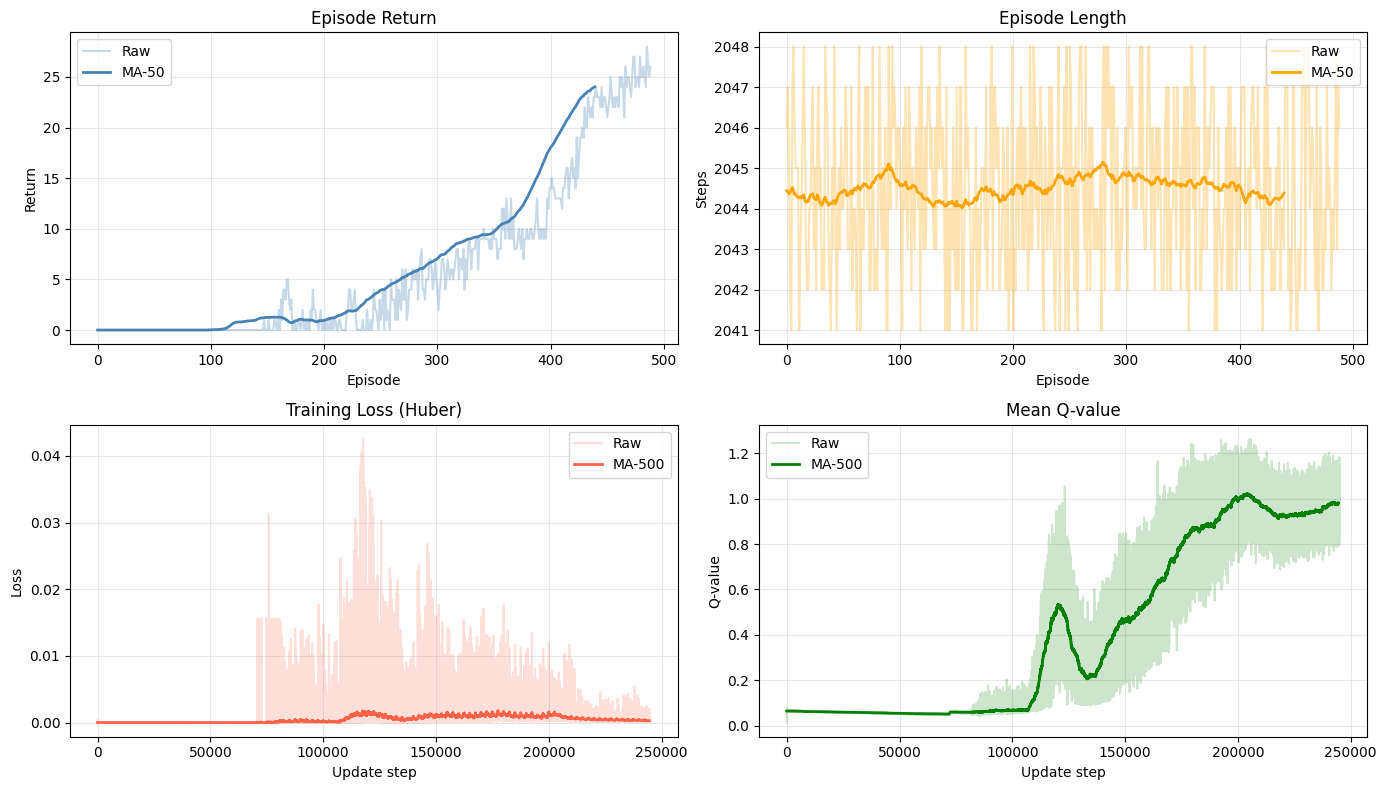

Saved: training_curves.png


In [12]:
def plot_training_curves(run: dict):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    def moving_average(data, window=50):
        if len(data) < window:
            return np.array(data)
        return np.convolve(data, np.ones(window) / window, mode='valid')

    #Episode returns
    axes[0, 0].plot(run['returns'], alpha=0.3, color='steelblue', label='Raw')
    axes[0, 0].plot(moving_average(run['returns'], 50), color='steelblue', linewidth=2, label='MA-50')
    axes[0, 0].set_title('Episode Return')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Return')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    #Episode lengths
    axes[0, 1].plot(run['lengths'], alpha=0.3, color='orange', label='Raw')
    axes[0, 1].plot(moving_average(run['lengths'], 50), color='orange', linewidth=2, label='MA-50')
    axes[0, 1].set_title('Episode Length')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('Steps')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    #Training loss
    axes[1, 0].plot(run['losses'], alpha=0.2, color='tomato', label='Raw')
    axes[1, 0].plot(moving_average(run['losses'], 500), color='tomato', linewidth=2, label='MA-500')
    axes[1, 0].set_title('Training Loss (Huber)')
    axes[1, 0].set_xlabel('Update step')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Mean Q-values
    axes[1, 1].plot(run['q_means'], alpha=0.2, color='green', label='Raw')
    axes[1, 1].plot(moving_average(run['q_means'], 500), color='green', linewidth=2, label='MA-500')
    axes[1, 1].set_title('Mean Q-value')
    axes[1, 1].set_xlabel('Update step')
    axes[1, 1].set_ylabel('Q-value')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")


plot_training_curves(run)

In [13]:
def _select_eval_action(agent, obs):
    if hasattr(agent, "predict"):
        return int(agent.predict(obs))
    if hasattr(agent, "act"):
        return int(agent.act(obs))
    if callable(agent):
        return int(agent(obs))
    raise TypeError(
        "Unsupported agent interface. Provide either a callable agent(obs), "
        "an object with agent.act(obs), or an object with agent.predict(obs)."
    )


def evaluate_agent(agent, make_env_fn, n_episodes=10, seed=42, max_steps=5_000):
    """Evaluate a trained agent on several independent episodes.

    Parameters
    ----------
    agent : object or callable
        The trained policy to evaluate.

        This helper accepts any of the following interfaces:
        - `agent(obs) -> action`
        - `agent.act(obs) -> action`
        - `agent.predict(obs) -> action`

        The returned action must be convertible to `int` and must be valid for
        the environment.


    make_env_fn : callable
        A factory that creates a fresh environment for evaluation.

        Recommended pattern:
        ```python
        def make_env_fn(seed=None):
            return make_atari_env("ALE/Breakout-v5", seed=seed)
        ```

        The helper will try to call `make_env_fn(seed=...)`. If your factory
        does not accept a `seed` argument, it will fall back to calling
        `make_env_fn()`.

        The environment returned by `make_env_fn` should already include the
        same preprocessing and wrappers that you used during training.

    n_episodes : int, default=10
        Number of independent evaluation episodes.

    seed : int, default=42
        Base random seed. Episode `i` uses `seed + i`.

    max_steps : int, default=5000
        Maximum number of interaction steps per episode. This prevents the
        evaluation from running forever if an episode is unusually long.

    Returns
    -------
    dict
        A dictionary with the raw returns and lengths, plus aggregate summary
        statistics:
        - `returns`
        - `lengths`
        - `mean_return`
        - `std_return`
        - `mean_length`
        - `std_length`

    How to use
    ----------
    1. Finish training your DQN agent.
    2. Write a small environment factory that builds one fresh evaluation env.
    3. Pass either your greedy agent directly, or wrap it into a callable.
    4. Call `evaluate_agent(...)` and report the returned mean and standard
       deviation values in your notebook.

    Minimal example:
    ```python
    def make_env_fn(seed=None):
        return make_atari_env("ALE/Breakout-v5", seed=seed)

    def greedy_agent(obs):
        return select_action(q_network, obs, epsilon=0.0)

    eval_stats = evaluate_agent(greedy_agent, make_env_fn, n_episodes=10)
    print(eval_stats)
    ```
    """
    import numpy as np

    returns = []
    lengths = []

    for episode_idx in range(n_episodes):
        episode_seed = seed + episode_idx
        try:
            env = make_env_fn(seed=episode_seed)
        except TypeError:
            env = make_env_fn()

        obs, _ = env.reset(seed=episode_seed)
        episode_return = 0.0
        episode_length = 0

        for _ in range(max_steps):
            action = _select_eval_action(agent, obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            episode_return += float(reward)
            episode_length += 1

            if terminated or truncated:
                break

        returns.append(episode_return)
        lengths.append(episode_length)
        env.close()

    returns = np.asarray(returns, dtype=float)
    lengths = np.asarray(lengths, dtype=float)

    return {
        "returns": returns,
        "lengths": lengths,
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_length": float(np.mean(lengths)),
        "std_length": float(np.std(lengths)),
    }


**GREEDY EVALUATION**

In [17]:
online_net = run['online_net']
online_net.eval()

def make_env_fn(seed=None):
    return make_atari_env(seed=seed)

_action_space = make_atari_env().action_space

def greedy_agent(obs):
    return select_action(
        online_net,
        obs,
        epsilon=0.0,
        action_space=_action_space,
        device=DEVICE,
        rng=np.random.default_rng(0),
    )

eval_stats = evaluate_agent(greedy_agent, make_env_fn, n_episodes=10, seed=100)

print(f"  Evaluation Results — ALE/Freeway-v5")
print(f"  Mean return : {eval_stats['mean_return']:.2f} ± {eval_stats['std_return']:.2f}")
print(f"  Mean length : {eval_stats['mean_length']:.1f} ± {eval_stats['std_length']:.1f}")
print(f"  Per episode : {[round(r,1) for r in eval_stats['returns'].tolist()]}")

  Evaluation Results — ALE/Freeway-v5
  Mean return : 24.30 ± 0.64
  Mean length : 2044.9 ± 1.9
  Per episode : [25.0, 24.0, 24.0, 24.0, 25.0, 25.0, 25.0, 23.0, 24.0, 24.0]


**GIF RECORDING**

In [18]:
def record_gif(
    agent_fn,
    env_id=ENV_ID,
    seed=999,
    max_steps=2000,
    gif_path='rollout.gif',
    fps=15,
):
    env = gym.make(
        env_id,
        render_mode='rgb_array',
        frameskip=1,
        repeat_action_probability=0.0,
        full_action_space=False,
    )
    env = AtariPreprocessing(
        env,
        frame_skip=4,
        screen_size=84,
        grayscale_obs=True,
        scale_obs=False,
        terminal_on_life_loss=False,
    )
    env = FrameStackObservation(env, 4)

    obs, _ = env.reset(seed=seed)
    frames = []
    total_reward = 0.0

    for _ in range(max_steps):
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = agent_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    env.close()
    imageio.mimsave(gif_path, frames, fps=fps)
    print(f"GIF saved: {gif_path}")
    print(f"Episode return: {total_reward:.1f}")
    print(f"Frames recorded: {len(frames)}")


record_gif(greedy_agent)

GIF saved: rollout.gif
Episode return: 23.0
Frames recorded: 2000


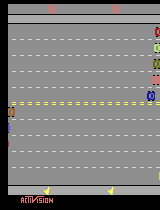

In [19]:
from IPython.display import Image, display
display(Image(filename='rollout.gif'))

**DISCUSSION:**

**Environment:** `ALE/Freeway-v5`

**Mean return: 24.30 ± 0.64**  
**Mean episode length: 2044.9 ± 1.9**

### Is the learned behaviour clearly better than random play?

A random policy on Freeway scores approximately 0 per
episode which it almost never gets the chicken across the highway it has no timing or direction strategy.

The trained DQN agent achieves a mean return of **24.30 ± 0.64** across
10 independent greedy episodes, which means it successfully crosses the
highway approximately 24 times per episode. The very low standard
deviation (±0.64) shows the policy is consistent and stable.

Looking at the training log, the agent started to return non-zero value
around step 300,000 (episode 150), then improved rapidly.

This clear upward trend confirms the agent learned a
meaningful policy, it learned to avoid cars and consistently cross the highway, rather than getting pushed back repeatedly like a random agent.

## Evaluation Requirement

For submission, your notebook should contain the following for **one Atari environment other than Pong**:

- the exact environment ID you used,
- one completed DQN training run on that environment,
- greedy evaluation on **at least 10 independent episodes**,
- the final `mean return ± std return`,
- the final `mean episode length ± std episode length`,
- at least one training curve and one greedy rollout GIF,
- a short discussion of whether the learned behavior is clearly better than random play.

`Pong` submissions do not satisfy this homework requirement.
